<a href="https://colab.research.google.com/github/vishwesh-V/virtue-of-complexity/blob/main/nagel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =================================================================
# nagel.ipynb — Phase 3 critique (Nagel 2025)
# Claim: the "virtue" is volatility-timed momentum in disguise. In short
# windows the RFF timing forecast reduces to a recency-weighted, vol-scaled
# bet on recent returns. Counter-spec: build a plain vol-timed momentum
# strategy (NO predictors, NO RFF) and measure how much of the KMZ Sharpe
# it mechanically explains.
# =================================================================
from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ    = "/content/drive/MyDrive/Summer Research/kmz"
DEBATE = "/content/drive/MyDrive/Summer Research/debate"
MASTER_SEED = 42

# --- engine copied from kmz_pipeline.ipynb — keep in sync ---
def make_rff(G, n_pairs, gamma=2.0, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((G.shape[1], n_pairs))
    proj = gamma * (G @ W)
    return np.concatenate([np.sin(proj), np.cos(proj)], axis=1)

def ridge_forecast_dual(S_tr, R_tr, S_t, z):
    T = S_tr.shape[0]
    K = (S_tr @ S_tr.T) / T
    a = np.linalg.solve(K + z*np.eye(T), R_tr/T)
    return float(S_t @ (S_tr.T @ a))

def run_oos_nested(S_full, R, P, T, z):
    S_all = S_full[:, :P]; N = len(R); fc, sr = [], []
    for t in range(T, N):
        S_tr, R_tr = S_all[t-T:t], R[t-T:t]
        sd = S_tr.std(axis=0); sd[sd==0]=1.0
        f = ridge_forecast_dual(S_tr/sd, R_tr, S_all[t]/sd, z)
        fc.append(f); sr.append(f*R[t])
    return np.array(fc), np.array(sr)


Mounted at /content/drive


In [2]:
predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]
panel = pd.read_parquet(f"{KMZ}/predictors.parquet").sort_values("date").reset_index(drop=True)
panel["target"] = panel["excess_ret"].shift(-1)

def exp_std(s, mp=36):
    return s / s.expanding(min_periods=mp).std().shift(1)
def vol_std_ret(r, w=12):
    return r / np.sqrt((r**2).rolling(w).mean()).shift(1)

std = panel.copy()
for c in predictors: std[c] = exp_std(panel[c])
std = std.dropna(subset=predictors+["target"]).reset_index(drop=True)
G = std[predictors].to_numpy()
R = std["target"].to_numpy()
# raw (unstandardized) excess return series, aligned — for the momentum benchmark
ret_series = std["excess_ret"].to_numpy()      # this month's realized excess return
print("data ready:", G.shape, R.shape)


data ready: (1152, 15) (1152,)


In [3]:
# =================================================================
# Vol-timed momentum: position_t = (recent return sign/size) / (recent vol)
# Uses NO predictors and NO RFF — just the return series itself.
# This is the "mechanical" strategy Nagel says explains the virtue.
# =================================================================
def vol_timed_momentum(ret, mom_window=12, vol_window=12):
    """position = trailing mom_window mean return, scaled by trailing vol.
    Bet long after positive recent returns, sized down when recent vol is high."""
    N = len(ret); strat = []
    for t in range(max(mom_window, vol_window), N-1):
        mom = ret[t-mom_window:t].mean()                    # recent momentum
        vol = np.sqrt((ret[t-vol_window:t]**2).mean())      # recent vol
        pos = mom / (vol + 1e-8)                            # vol-scaled bet
        strat.append(pos * ret[t+1])                        # next-month payoff
    return np.array(strat)

mom_strat = vol_timed_momentum(ret_series)
mom_sharpe = mom_strat.mean()/mom_strat.std()*np.sqrt(12)
print(f"Vol-timed momentum Sharpe (no predictors, no RFF): {mom_sharpe:.3f}")

Vol-timed momentum Sharpe (no predictors, no RFF): 0.283


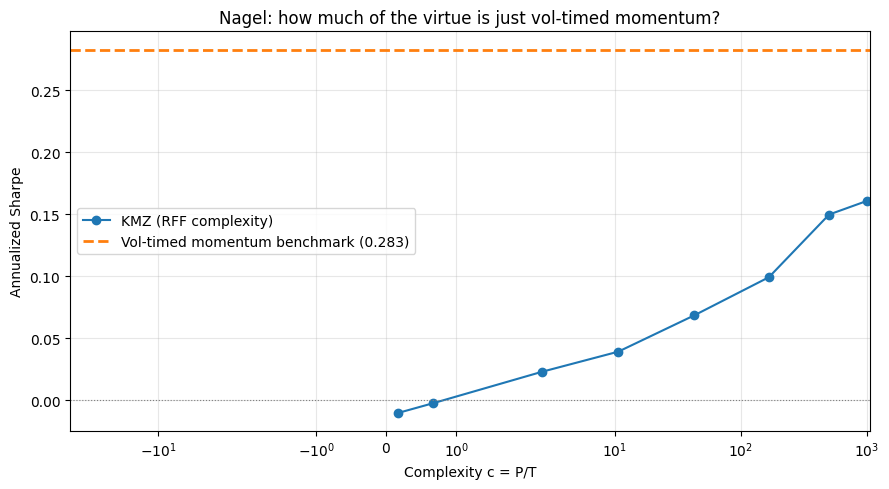

In [4]:
# KMZ Sharpe across complexity (recompute a few points, or load kmz_sweep_avg)
kmz = pd.read_parquet(f"{KMZ}/kmz_sweep_avg.parquet")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(kmz["complexity"], kmz["sharpe"], "o-", label="KMZ (RFF complexity)")
ax.axhline(mom_sharpe, color="C1", ls="--", lw=2,
           label=f"Vol-timed momentum benchmark ({mom_sharpe:.3f})")
ax.set_xscale("symlog"); ax.axhline(0, color="grey", lw=.8, ls=":")
ax.set_xlabel("Complexity c = P/T"); ax.set_ylabel("Annualized Sharpe")
ax.set_title("Nagel: how much of the virtue is just vol-timed momentum?")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
fig.savefig(f"{DEBATE}/nagel_momentum.png", dpi=150, bbox_inches="tight")